In [1]:
import control as ct
import matplotlib.pyplot as plt

In [2]:
s = ct.TransferFunction.s
G = 1 / (s * (s + 2))

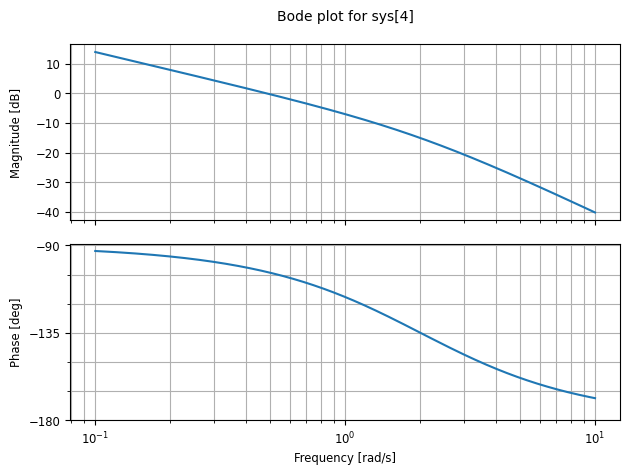

In [3]:
ct.bode(G, dB=True)

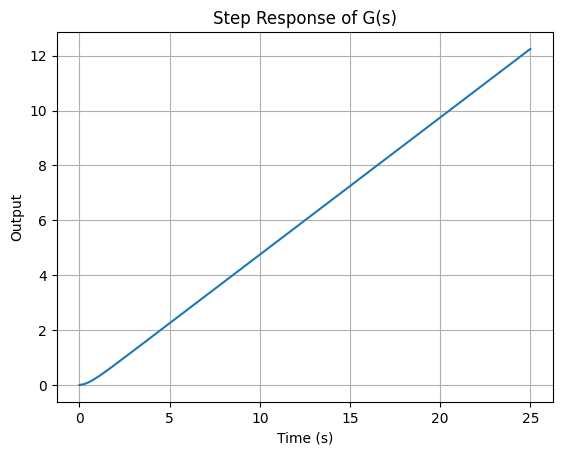

In [4]:
t, y = ct.step_response(G)
plt.plot(t, y)
plt.title('Step Response of G(s)')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid()

#### Lead Compensator
Adds positive phase → improves stability and speed.
* Moves system faster
* Increases phase margin

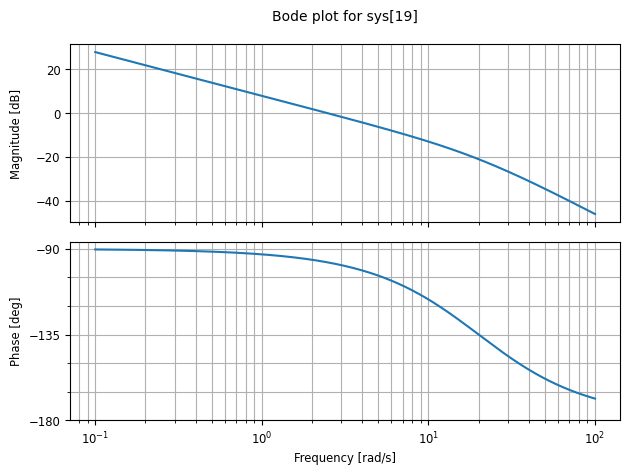

In [5]:
# Lead compensator parameters
K = 5
T = 0.5
alpha = 0.1   # alpha < 1 → phase lead

C_lead = K * (T*s + 1) / (alpha*T*s + 1)

# Open-loop system
L = C_lead * G

ct.bode(L, dB=True)

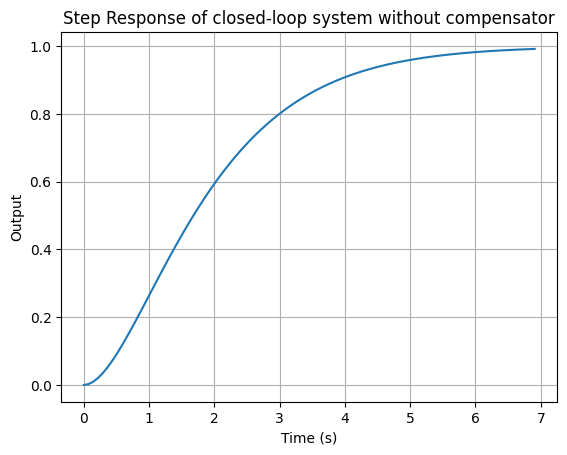

In [6]:
t, y = ct.step_response(ct.feedback(G))
plt.plot(t, y)
plt.title('Step Response of closed-loop system without compensator')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid()

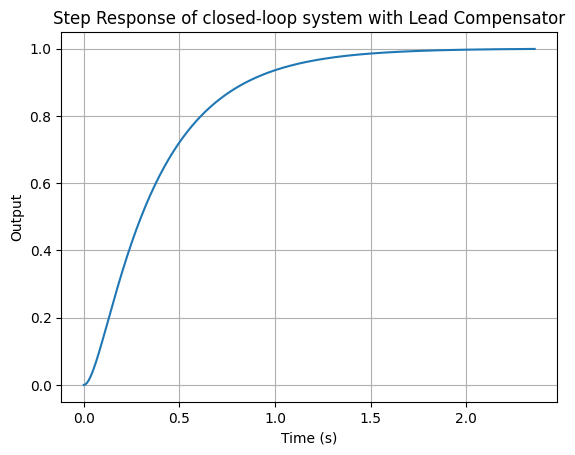

In [7]:
t, y = ct.step_response(ct.feedback(L))
plt.plot(t, y)
plt.title('Step Response of closed-loop system with Lead Compensator')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid()

#### Lag Compensator
Improves steady-state accuracy (reduces steady-state error)
* Improves low-frequency gain
* Slows system slightly

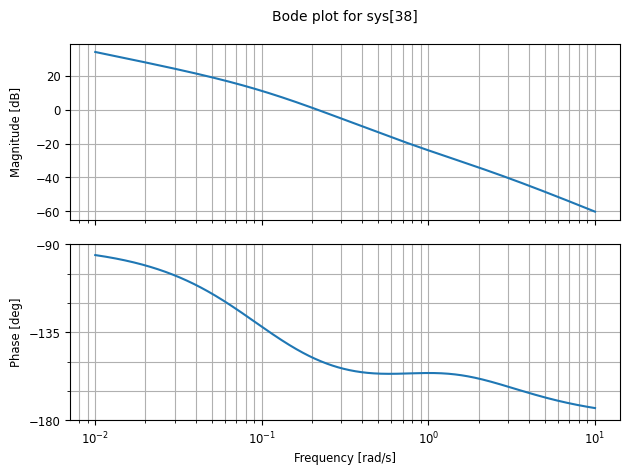

In [8]:
alpha = 10   # alpha > 1 → phase lag
T = 1

C_lag = (T*s + 1) / (alpha*T*s + 1)
L = C_lag * G

ct.bode(L, dB=True)

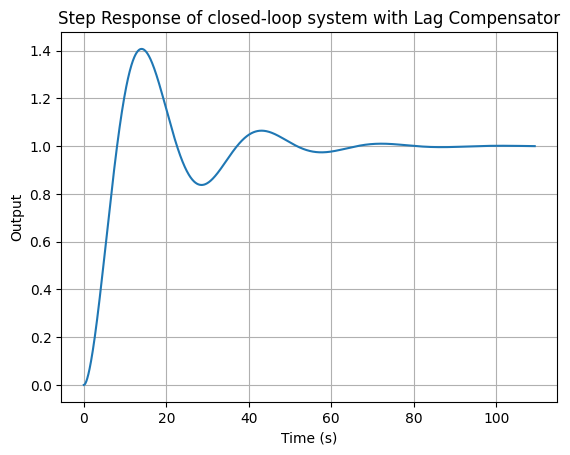

In [9]:
t, y = ct.step_response(ct.feedback(L))
plt.plot(t, y)
plt.title('Step Response of closed-loop system with Lag Compensator')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid()